# MDMP library demo — retail sales case study

End-to-end tour of the **mdmp** public API on daily retail SKU sales
(`data/MDM_retail_dataset.csv`).

| Layer | What we show |
| --- | --- |
| **Product MDM** | Structure + dynamics on all 15 SKUs |
| **Anomalies** | Predictive flags, panels ordered by **C3** and **C4** |
| **Aggregated DAGs** | MDM on summed C3 (7 nodes) and C4 (12 nodes) series |
| **IS / VTS** | **Monthly** subjects with shared semantic nodes (N=7) |
| **GS** | Food groups (`food_N3`) and product lags (`products_N3`) |

**Individual vs group.** One `MDM` models a single multivariate series. Group tools
need a cohort with equal node count `N`:

- **VTS / IS** — prefer **shared node meaning** across subjects → monthly panels
- **GS** — only needs equal `N` → food groups or lag-embedded products

Companion notebooks: `../05-is-aggregation.ipynb`, `../08-gs-distance-projection.ipynb`.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prefer the notebook's own directory (VS Code / Cursor sets __vsc_ipynb_file__)
DEMO = Path('.')

PKG_ROOT = DEMO.parent.parent  # .../mdmp (installable project root)
sys.path.insert(0, str(PKG_ROOT))
sys.path.insert(0, str(DEMO))

from retail_helpers import (
    C3_LABELS,
    C4_LABELS,
    DAG_LABELS,
    SKU_DAG_LABELS,
    aggregate_by_level,
    cohort_summary,
    food_group_subjects,
    monthly_subjects,
    one_sku_per_type,
    order_skus_by_level,
    parse_retail_dataset,
    product_lag_subjects,
)

from mdmp import (
    MDM,
    aggregate_individual_structures,
    compute_mdm_distance,
    compute_vts,
    detect_anomalies,
    fit_individual_structures,
    nearest_neighbours,
    plot_anomalies,
    plot_arcs,
    plot_dag,
    plot_group_embedding,
    plot_marginal,
    plot_stream,
    suggest_clusters,
)

NBF = 15
NBF_MONTHLY = 10  # T per month is ~28–31
CI_LEVEL = 0.95
plt.rcParams["figure.figsize"] = (10, 5)
print("demo:", DEMO)
print("mdmp root:", PKG_ROOT)

demo: .
mdmp root: .


## 1. Load & hierarchy

CSV has no header: three hierarchy rows (product type / line / item), then 180 daily rows.
Node names are `Line|Item`.

In [3]:
sales, hierarchy = parse_retail_dataset()
skus = [c for c in sales.columns if c != "Time"]
print(sales.shape, f"{sales['Time'].min().date()} -> {sales['Time'].max().date()}")
print(f"{len(skus)} SKUs | C3 types: {hierarchy['type'].nunique()} | C4 lines: {hierarchy['line'].nunique()}")
hierarchy

(180, 16) 2024-01-01 -> 2024-06-28
15 SKUs | C3 types: 7 | C4 lines: 12


,type,line,item
Cerveja|Lata,Alcoolicas,Cerveja,Lata
Cerveja|Latao,Alcoolicas,Cerveja,Latao
Cerveja|Retornavel 250ml,Alcoolicas,Cerveja,Retornavel 250ml
Arroz|5kg,Cereais Básicos,Arroz,5kg
Feijao|1kg,Cereais Básicos,Feijao,1kg
Pao|Forma,Padaria,Pao,Forma
Oleo_Soja|1L,Conservas,Oleo_Soja,1L
Molho_Tomate|250g,Conservas,Molho_Tomate,250g
Leite|Integral,Leite,Leite,Integral
Iogurte|Natural,Leite,Iogurte,Natural


## 2. Product MDM (15 SKUs)

Fit one MDM on the full product panel. Graphviz-style DAG uses short English labels.

In [4]:
sku_order = hierarchy.sort_values(["type", "line", "item"]).index.tolist()
panel = sales.loc[:, sku_order].copy()
panel.index = sales["Time"]

product_mdm = MDM(panel, method="hc", nbf=NBF, verbose=True, n_jobs=-1)
print("edges:", int(np.sum(product_mdm.adj_mat)))
print("DF_hat:", np.round(product_mdm.DF["DF_hat"], 3))

Learning structure using method: hc


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Cerveja|Lata': 'N', 'Cerveja|Latao': 'N', 'Cerveja|Retornavel 250ml': 'N', 'Arroz|5kg': 'N', 'Feijao|1kg': 'N', 'Molho_Tomate|250g': 'N', 'Oleo_Soja|1L': 'N', 'Iogurte|Natural': 'N', 'Leite|Integral': 'N', 'Refrigerante|Lata': 'N', 'Refrigerante|Retornavel 1.5L': 'N', 'Suco_Natural|1L': 'N', 'Pao|Forma': 'N', 'Cereal_Barra|250g': 'N', 'Chocolate|Leite 1kg': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Cerveja|Lata': 'N', 'Cerveja|Latao': 'N', 'Cerveja|Retornavel 250ml': 'N', 'Arroz|5kg': 'N', 'Feijao|1kg': 'N', 'Molho_Tomate|250g': 'N', 'Oleo_Soja|1L': 'N', 'Iogurte|Natural': 'N', 'Leite|Integral': 'N', 'Refrigerante|Lata': 'N', 'Refrigerante|Retornavel 1.5L': 'N', 'Suco_Natural|1L': 'N', 'Pao|Forma': 'N', 'Cereal_Barra|250g': 'N', 'Chocolate|Leite 1kg': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unorder

Selecting discount factors...


Selecting discount factors: 100%|██████████| 765/765 [00:05<00:00, 150.29it/s]


Computing filtered estimates...


Filtering nodes: 100%|██████████| 15/15 [00:04<00:00,  3.62it/s]


Computing smoothed estimates...


Smoothing nodes: 100%|██████████| 15/15 [00:04<00:00,  3.58it/s]



MDM processing completed in 1m 13.46s
edges: 24
DF_hat: [0.5  1.   1.   1.   0.98 0.98 0.97 0.98 0.97 1.   0.98 1.   0.97 0.88
 0.5 ]


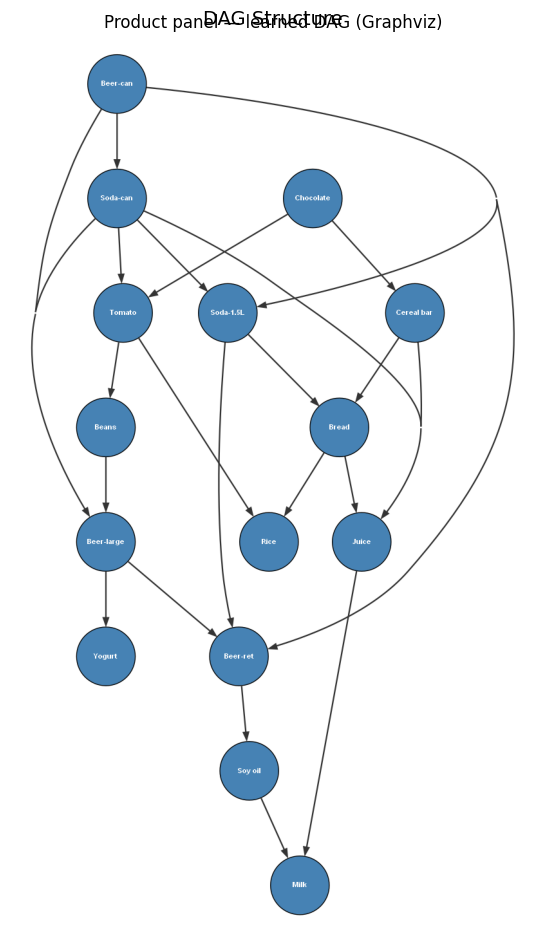

dynamics child: Cerveja|Latao | n_parents: 3


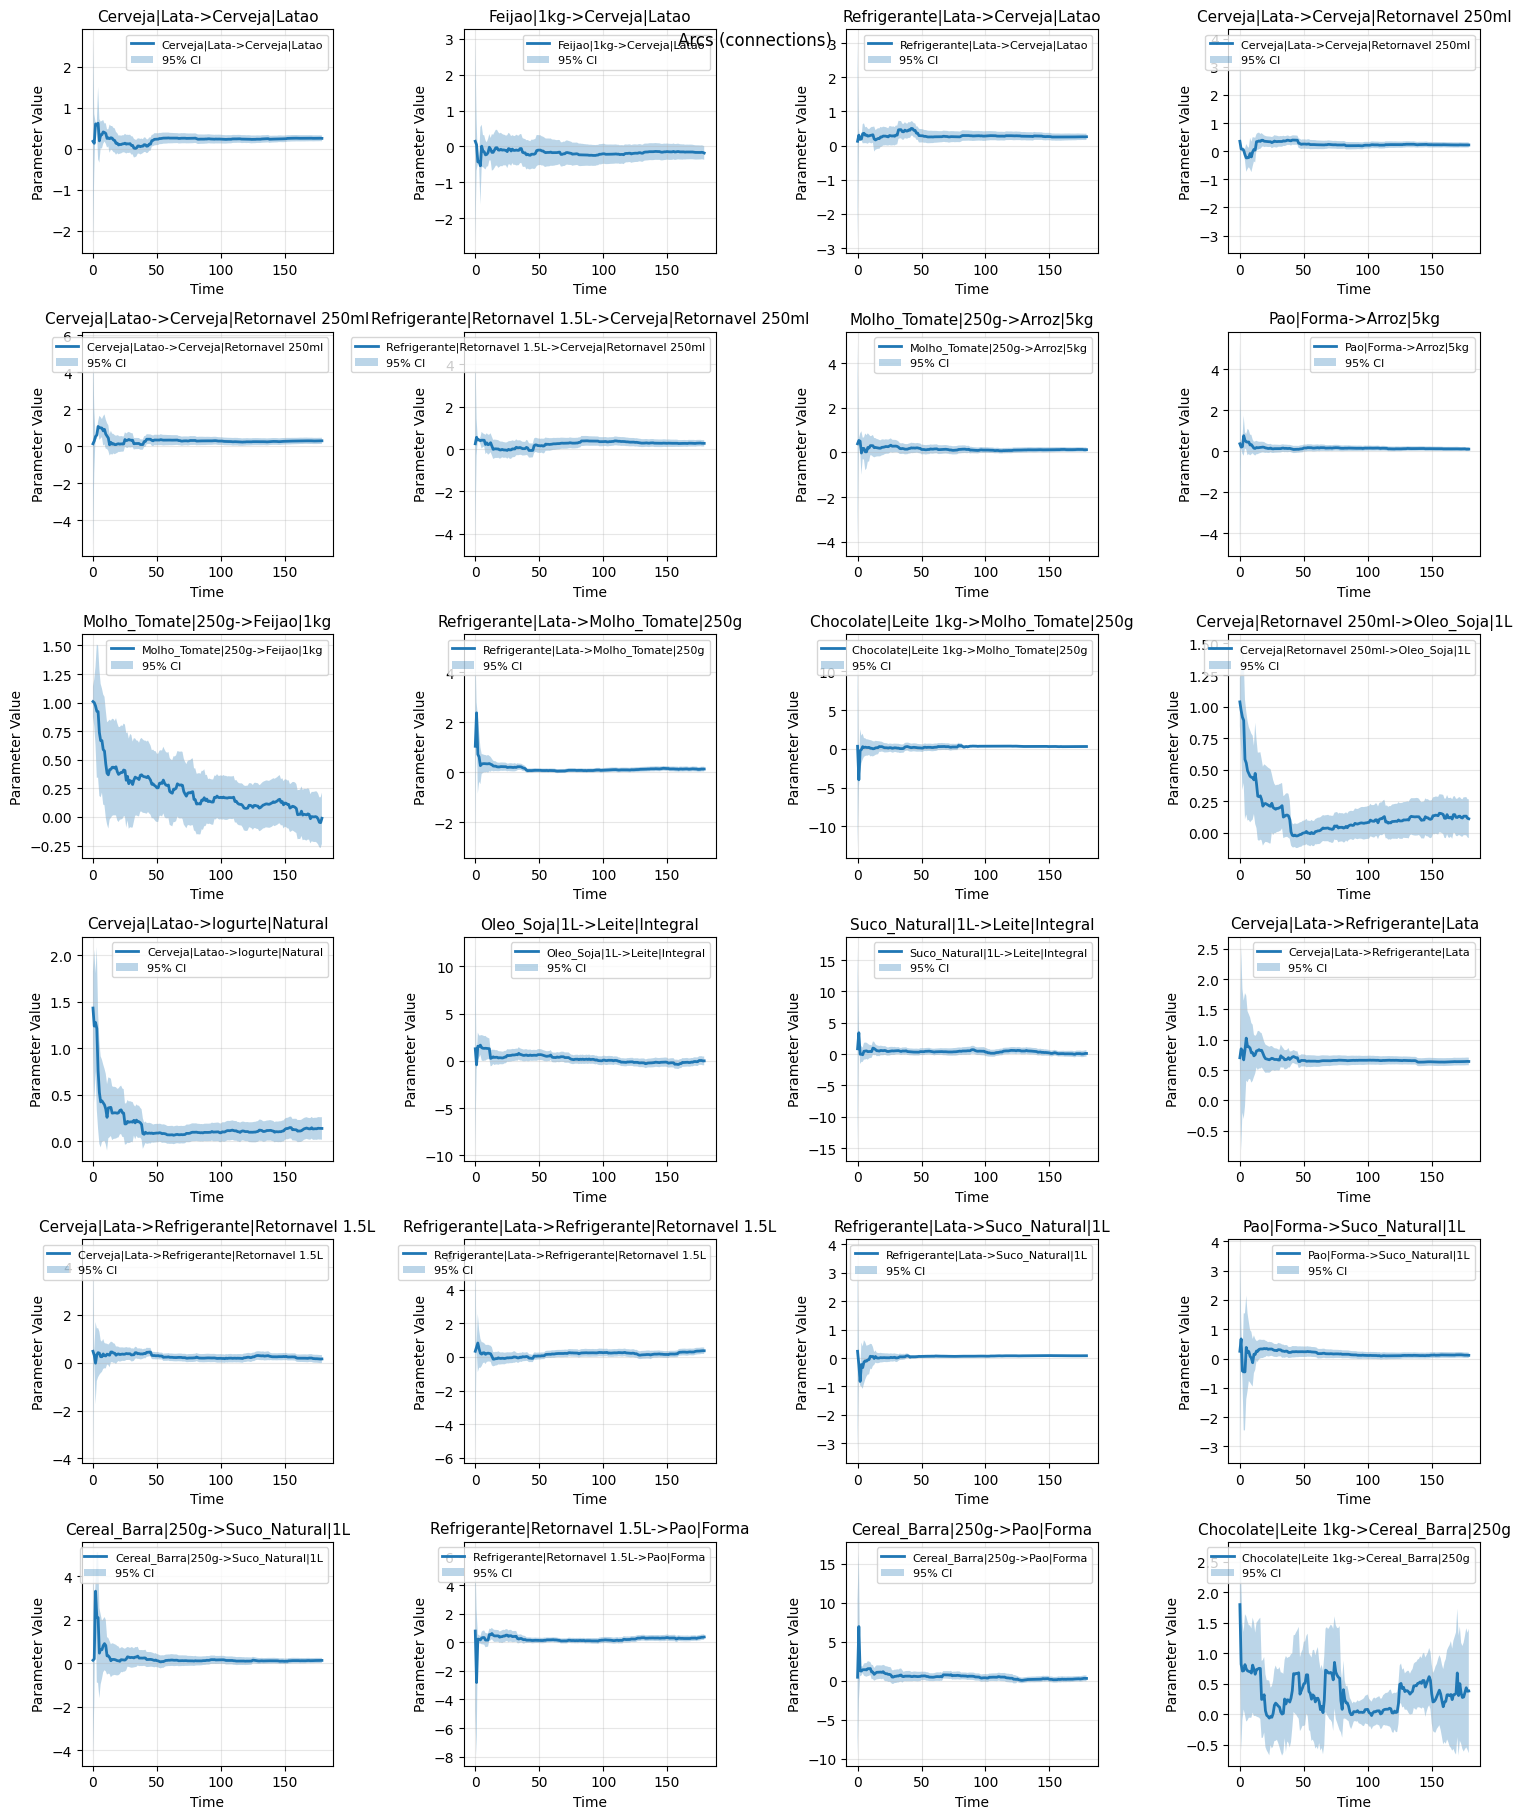

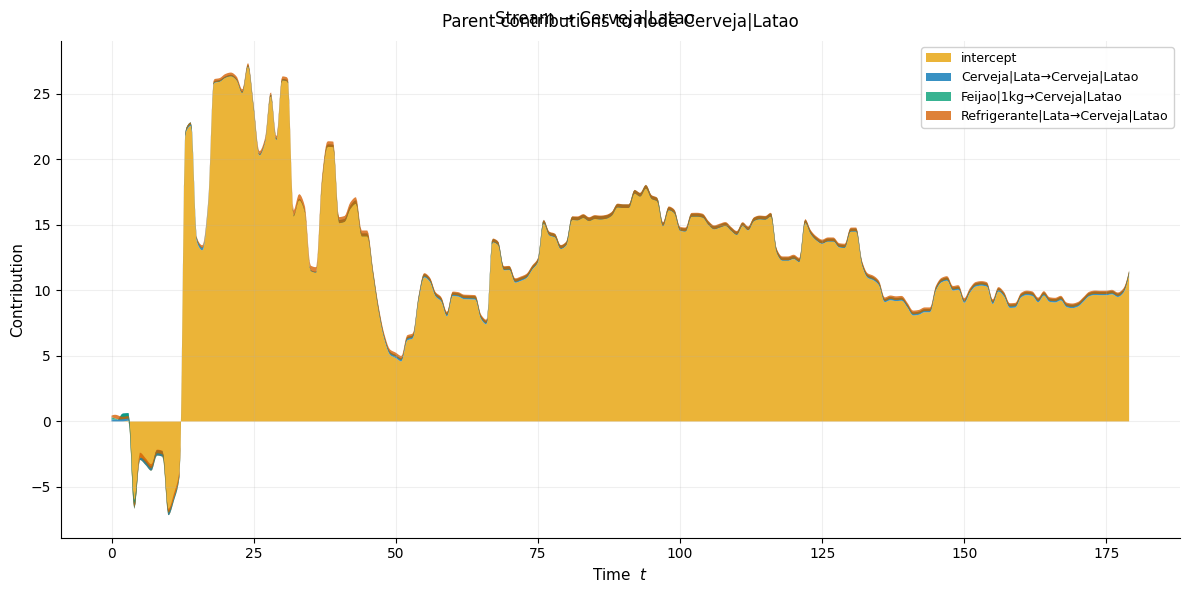

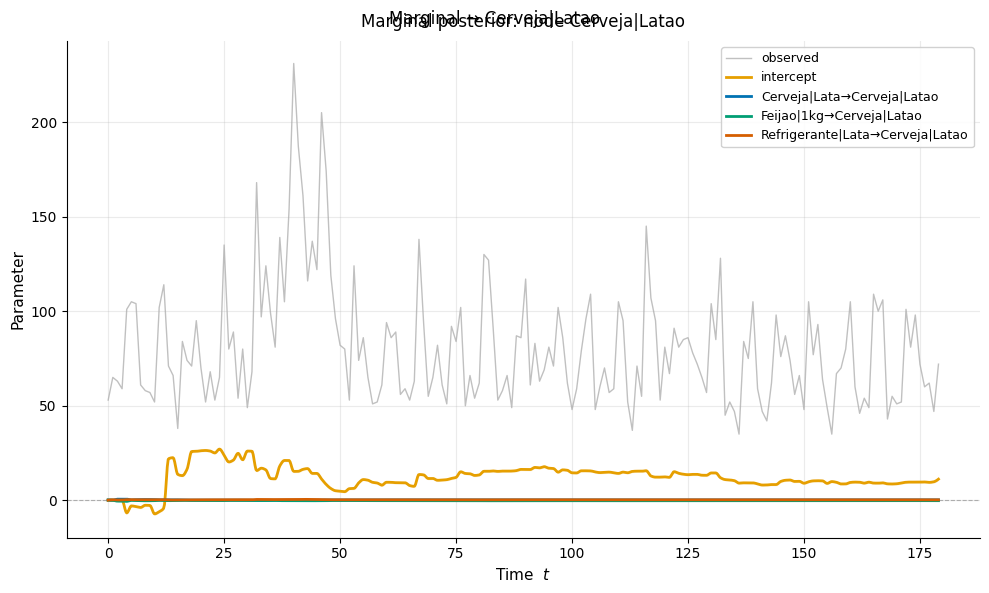

In [5]:
short_labels = [SKU_DAG_LABELS.get(s, s) for s in sku_order]

fig = plot_dag(product_mdm, node_labels=short_labels, style="graphviz")
plt.suptitle("Product panel — learned DAG (Graphviz)")
plt.show()

adj = np.asarray(product_mdm.adj_mat)
parents_per_child = adj.sum(axis=0)
child_idx = int(np.argmax(parents_per_child)) if parents_per_child.max() > 0 else 0
child_name = sku_order[child_idx]
print("dynamics child:", child_name, "| n_parents:", int(parents_per_child[child_idx]))

plot_arcs(product_mdm, plot_type="connections")
plt.suptitle("Arcs (connections)")
plt.show()

plot_stream(product_mdm, child_node=child_idx)
plt.suptitle(f"Stream → {child_name}")
plt.show()

plot_marginal(product_mdm, target_node=child_idx)
plt.suptitle(f"Marginal → {child_name}")
plt.show()

## 3. Anomalies by C3 and C4

Anomalies use the **product** MDM (not aggregated). Panels are only **reordered** so SKUs
from the same C3 Product Line or C4 Product Type sit together.

total anomaly flags: 128 / 2700
                          n_anomalies
node                                 
Cerveja|Retornavel 250ml           14
Cereal_Barra|250g                  13
Suco_Natural|1L                    12
Chocolate|Leite 1kg                11
Cerveja|Latao                      10
Refrigerante|Lata                  10
Pao|Forma                           8
Cerveja|Lata                        7
Feijao|1kg                          7
Molho_Tomate|250g                   7


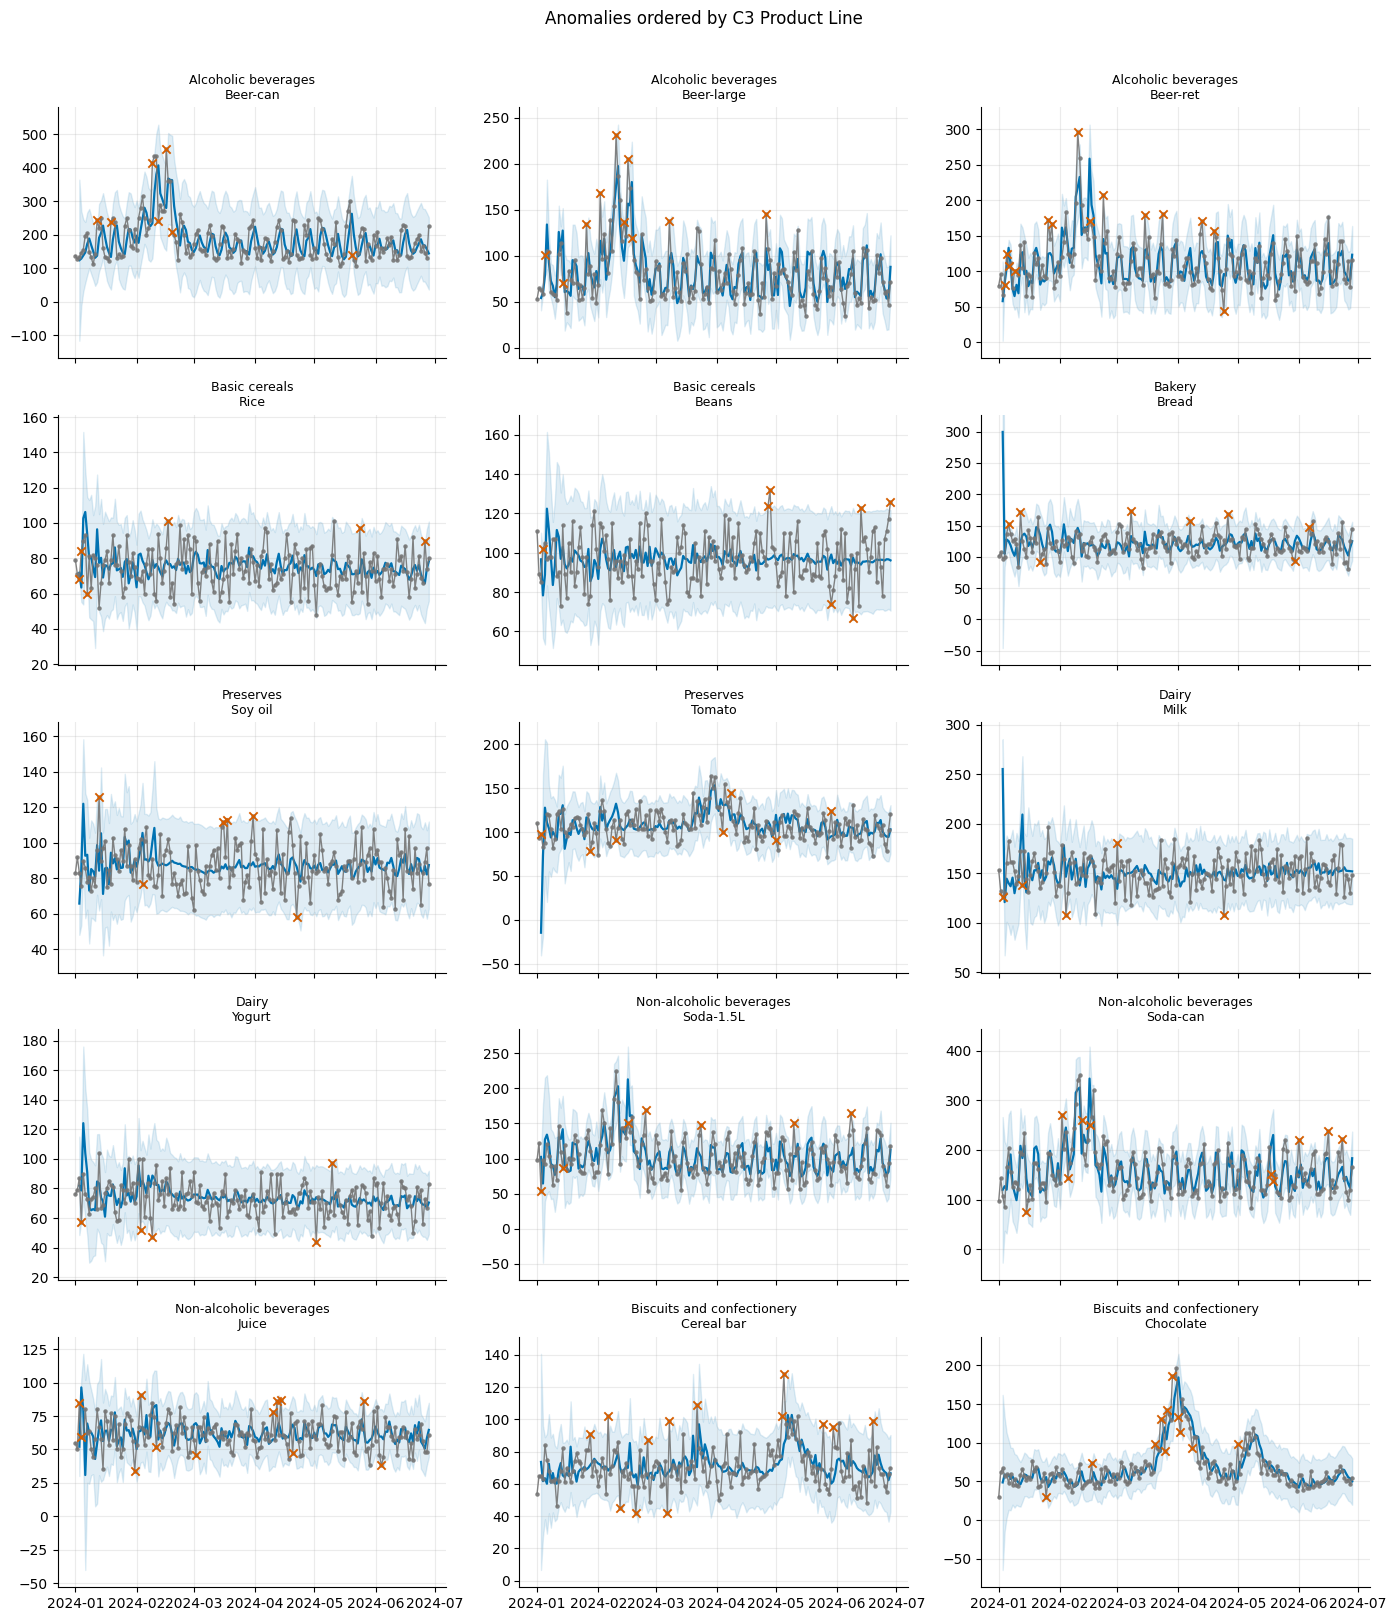

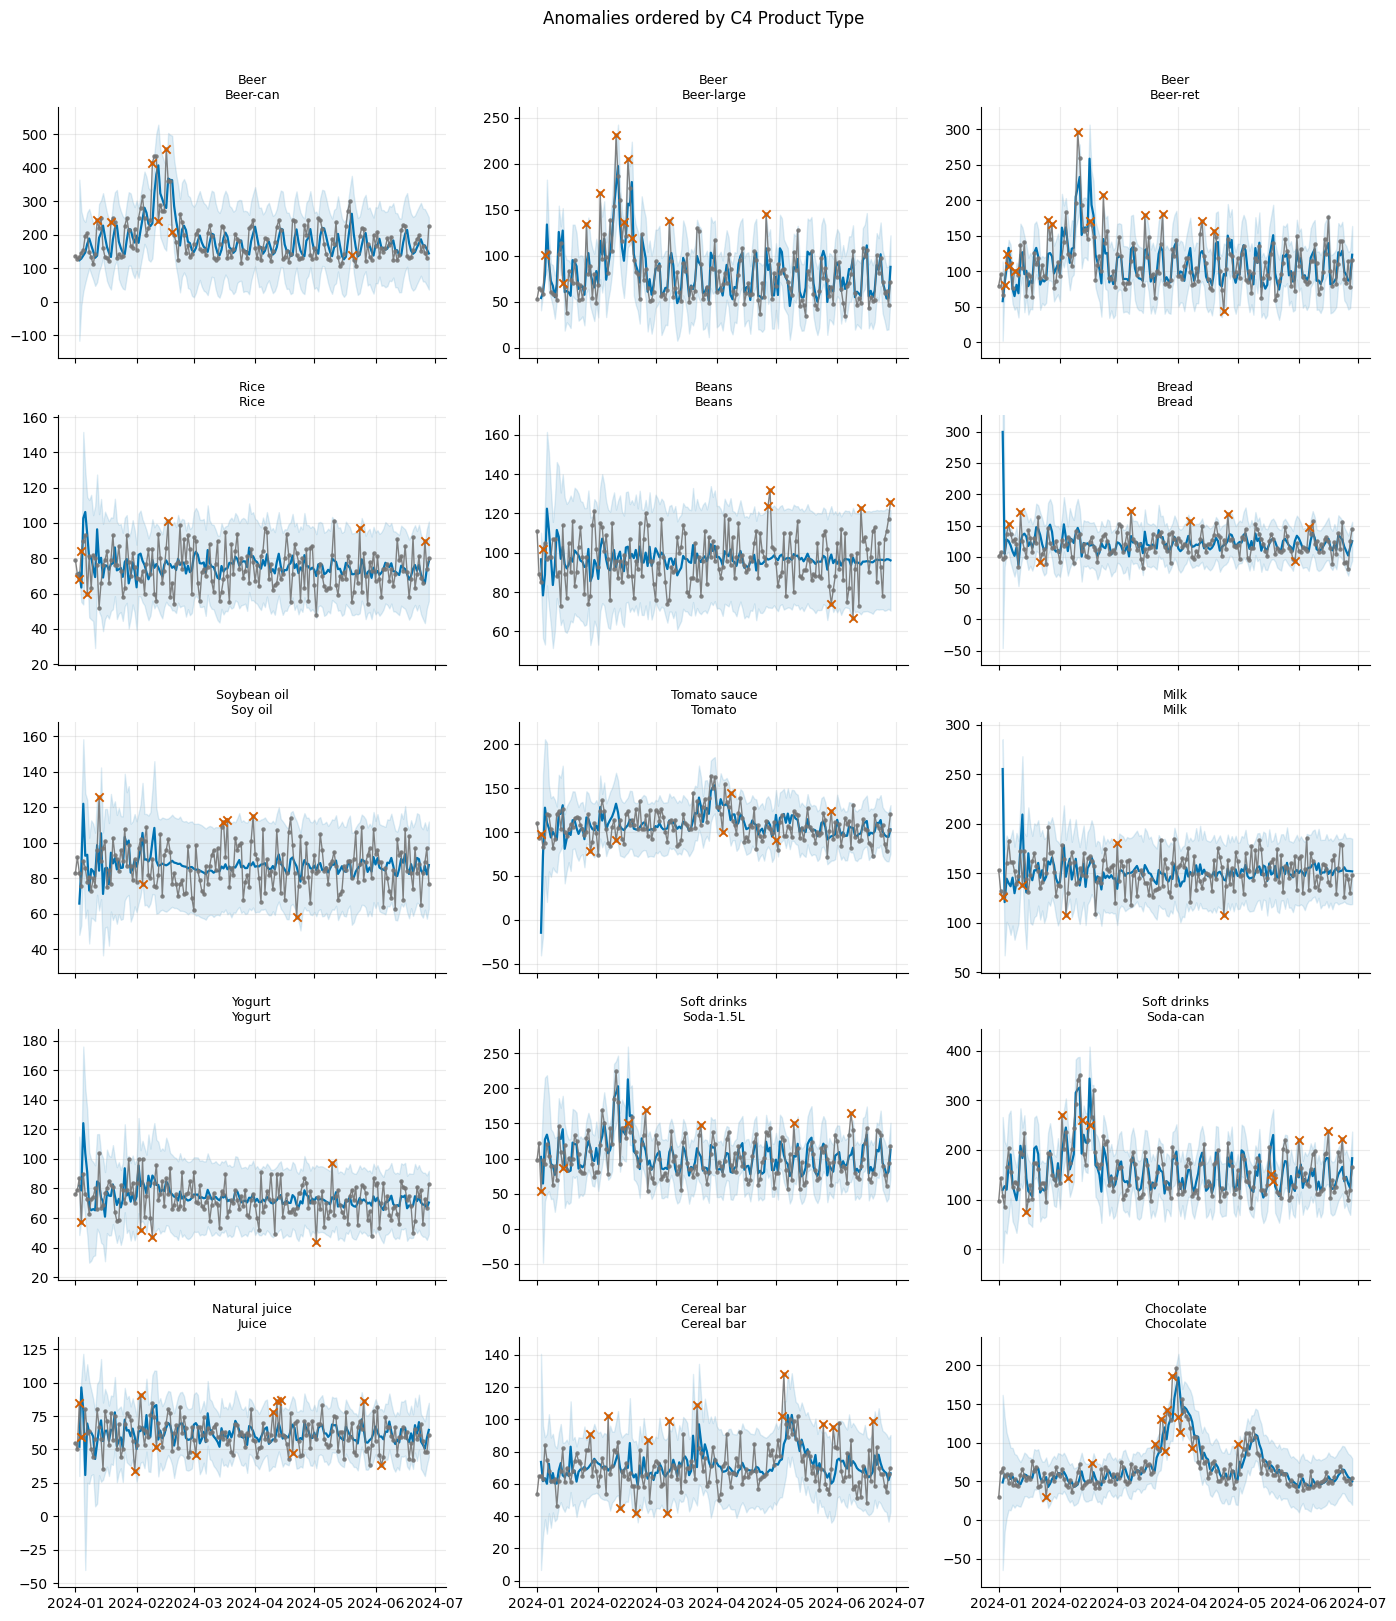

In [6]:
anom = detect_anomalies(
    product_mdm,
    ci_level=CI_LEVEL,
    series=None,
    output="dataframe",
    time_index=list(panel.index),
)
counts = (
    anom.groupby("node")["is_anomaly"]
    .sum()
    .astype(int)
    .rename("n_anomalies")
    .sort_values(ascending=False)
)
print(f"total anomaly flags: {int(anom['is_anomaly'].sum())} / {len(anom)}")
print(counts.head(10).to_frame())


def plot_anomaly_grid(level_key: str, title: str) -> None:
    ordered = order_skus_by_level(hierarchy, level_key)
    n_sku = len(ordered)
    ncols = 3
    nrows = int(np.ceil(n_sku / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    col = "type" if level_key == "type" else "line"
    label_map = C3_LABELS if level_key == "type" else C4_LABELS
    for ax, sku in zip(axes, ordered):
        group = hierarchy.loc[sku, col]
        group_en = label_map.get(group, group)
        plot_anomalies(
            product_mdm,
            series=sku,
            ci_level=CI_LEVEL,
            ax=ax,
            time_index=list(panel.index),
        )
        ax.set_title(f"{group_en}\n{SKU_DAG_LABELS.get(sku, sku)}", fontsize=9)
    for ax in axes[n_sku:]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_anomaly_grid("type", "Anomalies ordered by C3 Product Line")
plot_anomaly_grid("line", "Anomalies ordered by C4 Product Type")

## 4. Aggregated C3 / C4 DAGs

Sum SKU sales within each hierarchy level, then fit a separate MDM on the aggregated
multivariate series (7 C3 nodes, 12 C4 nodes).

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Alcoholic beverages': 'N', 'Basic cereals': 'N', 'Bakery': 'N', 'Preserves': 'N', 'Dairy': 'N', 'Non-alcoholic beverages': 'N', 'Biscuits and confectionery': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Alcoholic beverages': 'N', 'Basic cereals': 'N', 'Bakery': 'N', 'Preserves': 'N', 'Dairy': 'N', 'Non-alcoholic beverages': 'N', 'Biscuits and confectionery': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Alcoholic beverages': 'N', 'Basic cereals': 'N', 'Bakery': 'N', 'Preserves': 'N', 'Dairy': 'N', 'Non-alcoholic beverages': 'N', 'Biscuits and confectionery': 'N'}


C3: (180, 7) ['Alcoholic beverages', 'Basic cereals', 'Bakery', 'Preserves', 'Dairy', 'Non-alcoholic beverages', 'Biscuits and confectionery']
C4: (180, 12) ['Beer', 'Rice', 'Beans', 'Bread', 'Soybean oil', 'Tomato sauce', 'Milk', 'Yogurt', 'Soft drinks', 'Natural juice', 'Cereal bar', 'Chocolate']
Learning structure using method: hc


  0%|          | 8/1000000 [00:08<277:56:14,  1.00s/it] 


Selecting discount factors...


Selecting discount factors: 100%|██████████| 357/357 [00:05<00:00, 68.58it/s]


Computing filtered estimates...


Filtering nodes: 100%|██████████| 7/7 [00:02<00:00,  2.51it/s]


Computing smoothed estimates...


Smoothing nodes: 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]



MDM processing completed in 21.24 seconds


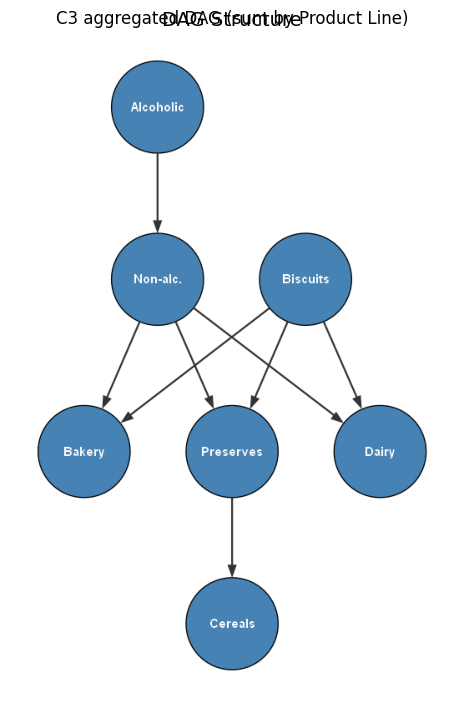

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer': 'N', 'Rice': 'N', 'Beans': 'N', 'Bread': 'N', 'Soybean oil': 'N', 'Tomato sauce': 'N', 'Milk': 'N', 'Yogurt': 'N', 'Soft drinks': 'N', 'Natural juice': 'N', 'Cereal bar': 'N', 'Chocolate': 'N'}


Learning structure using method: hc


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer': 'N', 'Rice': 'N', 'Beans': 'N', 'Bread': 'N', 'Soybean oil': 'N', 'Tomato sauce': 'N', 'Milk': 'N', 'Yogurt': 'N', 'Soft drinks': 'N', 'Natural juice': 'N', 'Cereal bar': 'N', 'Chocolate': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer': 'N', 'Rice': 'N', 'Beans': 'N', 'Bread': 'N', 'Soybean oil': 'N', 'Tomato sauce': 'N', 'Milk': 'N', 'Yogurt': 'N', 'Soft drinks': 'N', 'Natural juice': 'N', 'Cereal bar': 'N', 'Chocolate': 'N'}
  0%|          | 16/1000000 [00:28<503:19:37,  1.81s/it]


Selecting discount factors...


Selecting discount factors: 100%|██████████| 612/612 [00:05<00:00, 111.58it/s]


Computing filtered estimates...


Filtering nodes: 100%|██████████| 12/12 [00:04<00:00,  2.78it/s]


Computing smoothed estimates...


Smoothing nodes: 100%|██████████| 12/12 [00:05<00:00,  2.19it/s]



MDM processing completed in 47.55 seconds


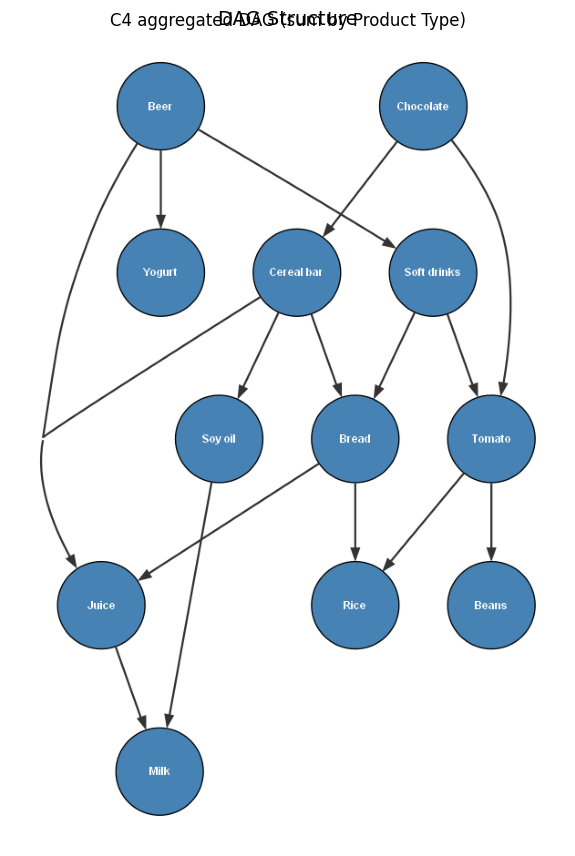

In [7]:
c3_data = aggregate_by_level(sales, hierarchy, "type")
c4_data = aggregate_by_level(sales, hierarchy, "line")
print("C3:", c3_data.shape, list(c3_data.columns))
print("C4:", c4_data.shape, list(c4_data.columns))

c3_mdm = MDM(c3_data, method="hc", nbf=NBF, verbose=True, n_jobs=-1)
c3_short = [DAG_LABELS.get(c, c) for c in c3_data.columns]
fig = plot_dag(c3_mdm, node_labels=c3_short, style="graphviz")
plt.suptitle("C3 aggregated DAG (sum by Product Line)")
plt.show()

c4_mdm = MDM(c4_data, method="hc", nbf=NBF, verbose=True, n_jobs=-1)
c4_short = [DAG_LABELS.get(c, c) for c in c4_data.columns]
fig = plot_dag(c4_mdm, node_labels=c4_short, style="graphviz")
plt.suptitle("C4 aggregated DAG (sum by Product Type)")
plt.show()

## 5. Monthly cohort for IS / VTS (shared nodes)

Treat each calendar month as a subject. Nodes are the **same** 7 SKUs across months
(one SKU per C3 type), so edges keep a fixed semantic meaning — required for
interpretable **IS** and **VTS**. Use `nbf=10` because each month has only ~28–31 days.

In [8]:
monthly_nodes = one_sku_per_type(hierarchy)
monthly_labels = [SKU_DAG_LABELS.get(s, s) for s in monthly_nodes]
print("monthly nodes (1 per C3 type):")
for sku, lab in zip(monthly_nodes, monthly_labels):
    print(f"  {lab:12s}  {sku}  [{hierarchy.loc[sku, 'type']}]")

subjects_m, subject_ids_m, node_names_m = monthly_subjects(
    sales, node_names=monthly_nodes
)
summary_m = cohort_summary(subjects_m, subject_ids_m, node_names_m)
print(summary_m)

monthly nodes (1 per C3 type):
  Beer-can      Cerveja|Lata  [Alcoolicas]
  Rice          Arroz|5kg  [Cereais Básicos]
  Bread         Pao|Forma  [Padaria]
  Soy oil       Oleo_Soja|1L  [Conservas]
  Milk          Leite|Integral  [Leite]
  Soda-1.5L     Refrigerante|Retornavel 1.5L  [Não-alcoólicas]
  Cereal bar    Cereal_Barra|250g  [biscoitos, bomboniere]
{'n_subjects': 6, 'n_nodes': 7, 'node_names': ['Cerveja|Lata', 'Arroz|5kg', 'Pao|Forma', 'Oleo_Soja|1L', 'Leite|Integral', 'Refrigerante|Retornavel 1.5L', 'Cereal_Barra|250g'], 'subject_ids': ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06'], 'T_per_subject': [31, 29, 31, 30, 31, 28], 'T_min': 28, 'T_max': 31, 'shapes': [(31, 7), (29, 7), (31, 7), (30, 7), (31, 7), (28, 7)]}


## 6. Fit MDM individually → VTS → IS

`fit_individual_structures` fits one MDM per month. Then:

- **VTS** averages the monthly panels and fits MDM on the representative series
- **IS** votes the six adjacency matrices into a consensus DAG

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}


[distance] fitting individual structure for subject 2024-01


  0%|          | 8/1000000 [00:01<60:06:52,  4.62it/s] 
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}


[distance] fitting individual structure for subject 2024-02


  0%|          | 8/1000000 [00:01<46:13:40,  6.01it/s] 
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}


...

[distance] fitting individual structure for subject 2024-05


  0%|          | 7/1000000 [00:01<74:54:16,  3.71it/s] 
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}


[distance] fitting individual structure for subject 2024-06


  0%|          | 7/1000000 [00:01<78:42:25,  3.53it/s] 


edges per month: {'2024-01': 8, '2024-02': 8, '2024-03': 7, '2024-04': 5, '2024-05': 7, '2024-06': 7}


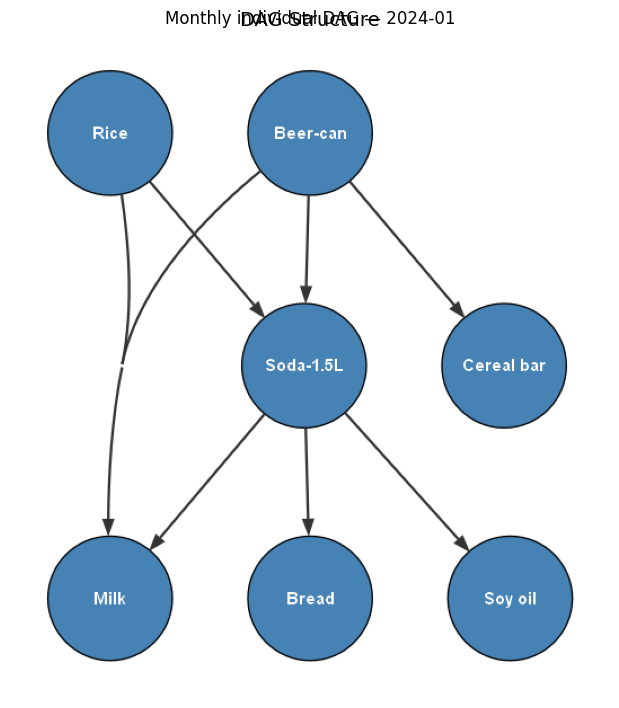

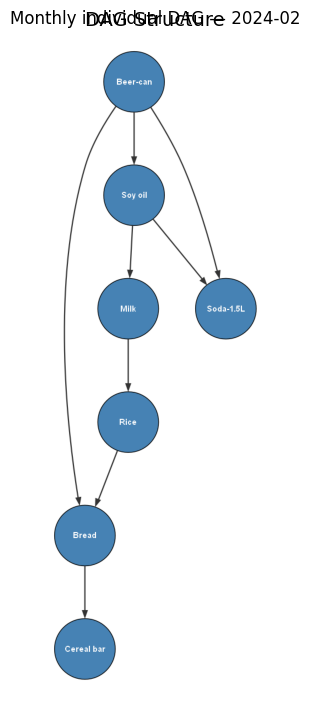

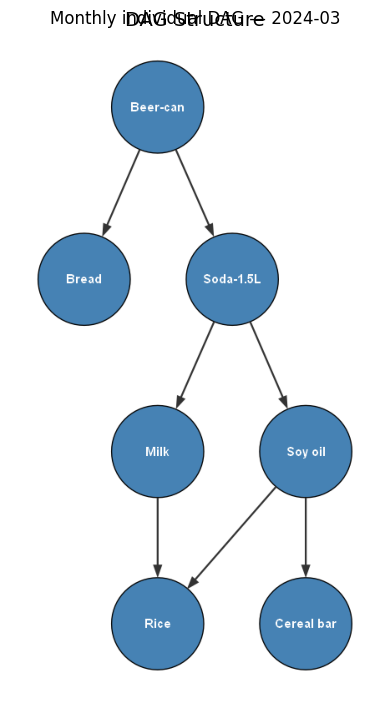

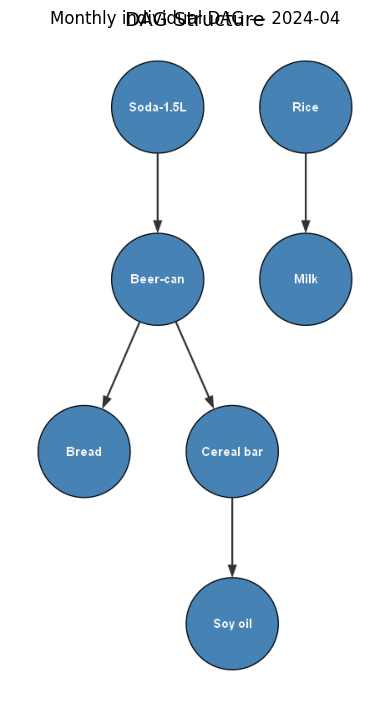

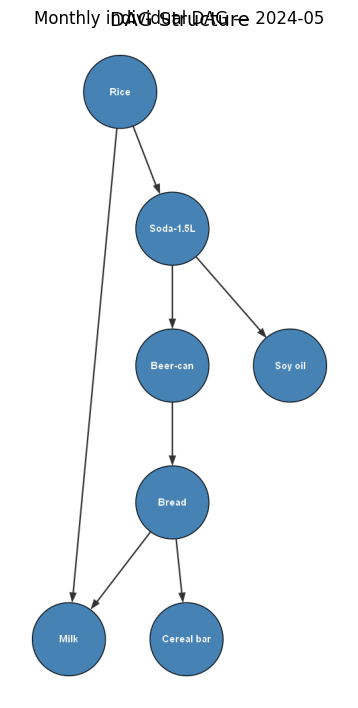

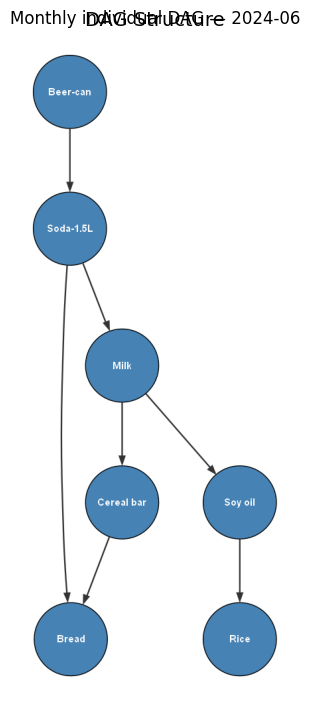

In [9]:
individuals_m = fit_individual_structures(
    subjects_m,
    method="hc",
    nbf=NBF_MONTHLY,
    node_names=monthly_labels,
    subject_ids=subject_ids_m,
    n_jobs=-1,
    verbose=True,
)
edge_counts = {
    sid: int(np.sum(m.adj_mat)) for sid, m in zip(subject_ids_m, individuals_m)
}
print("edges per month:", edge_counts)

for m, sid in zip(individuals_m, subject_ids_m):
    plot_dag(m, node_labels=monthly_labels, style="graphviz")
    plt.suptitle(f"Monthly individual DAG — {sid}")
    plt.show()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Beer-can': 'N', 'Rice': 'N', 'Bread': 'N', 'Soy oil': 'N', 'Milk': 'N', 'Soda-1.5L': 'N', 'Cereal bar': 'N'}


VTS shape: (28, 7) | method: mean | S: 6
Learning structure using method: hc


  0%|          | 7/1000000 [00:01<54:55:59,  5.06it/s] 


Selecting discount factors...


Selecting discount factors: 100%|██████████| 357/357 [00:05<00:00, 65.70it/s]


Computing filtered estimates...


Filtering nodes: 100%|██████████| 7/7 [00:02<00:00,  2.48it/s]


Computing smoothed estimates...


Smoothing nodes: 100%|██████████| 7/7 [00:02<00:00,  2.57it/s]



MDM processing completed in 14.62 seconds


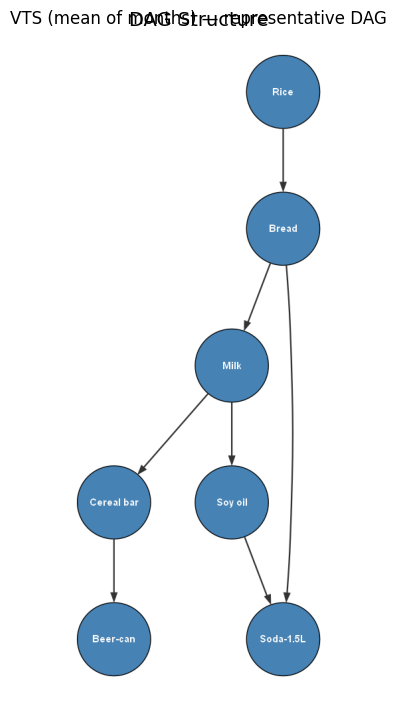

In [10]:
vts = compute_vts(subjects_m, method="mean")
print("VTS shape:", vts.vts_data.shape, "| method:", vts.method, "| S:", vts.n_subjects)

vts_df = pd.DataFrame(vts.vts_data, columns=monthly_labels)
vts_mdm = MDM(vts_df, method="hc", nbf=NBF_MONTHLY, verbose=True, n_jobs=-1)

fig = plot_dag(vts_mdm, node_labels=monthly_labels, style="graphviz")
plt.suptitle("VTS (mean of months) — representative DAG")
plt.show()

consensus edges: 2


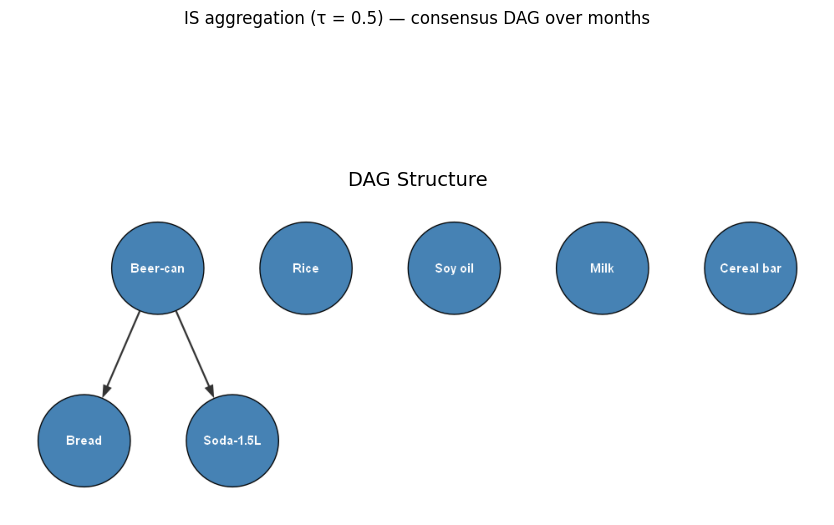

In [11]:
is_view = aggregate_individual_structures(
    [m.adj_mat for m in individuals_m],
    tau=0.5,
    node_names=monthly_labels,
)
print("consensus edges:", int(np.sum(is_view.adj_mat)))

fig = plot_dag(is_view, node_labels=monthly_labels, style="graphviz")
plt.suptitle("IS aggregation (τ = 0.5) — consensus DAG over months")
plt.show()

## 7. GS — food groups (`food_N3`)

Five food-group subjects, each with N=3 generic slots (`SKU1..SKU3`). Node meaning
differs across groups; GS only needs equal `N` for pairwise structure distance.

In [12]:
subjects_f, subject_ids_f, node_names_f, membership = food_group_subjects(sales)
print(cohort_summary(subjects_f, subject_ids_f, node_names_f))
pd.DataFrame(membership, index=node_names_f).T

{'n_subjects': 5, 'n_nodes': 3, 'node_names': ['SKU1', 'SKU2', 'SKU3'], 'subject_ids': ['Alcoolicas', 'Nao-alcoolicas', 'Cereais_Padaria', 'Leite_Conservas', 'Conservas_Biscoitos'], 'T_per_subject': [180, 180, 180, 180, 180], 'T_min': 180, 'T_max': 180, 'shapes': [(180, 3), (180, 3), (180, 3), (180, 3), (180, 3)]}


,SKU1,SKU2,SKU3
Alcoolicas,Cerveja|Lata,Cerveja|Latao,Cerveja|Retornavel 250ml
Nao-alcoolicas,Refrigerante|Retornavel 1.5L,Refrigerante|Lata,Suco_Natural|1L
Cereais_Padaria,Arroz|5kg,Feijao|1kg,Pao|Forma
Leite_Conservas,Leite|Integral,Iogurte|Natural,Oleo_Soja|1L
Conservas_Biscoitos,Molho_Tomate|250g,Cereal_Barra|250g,Chocolate|Leite 1kg


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}


[distance] fitting individual structure for subject Alcoolicas


  0%|          | 3/1000000 [00:01<149:12:43,  1.86it/s]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}


[distance] fitting individual structure for subject Nao-alcoolicas


  0%|          | 2/1000000 [00:01<253:52:09,  1.09it/s]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}


...

[distance] fitting individual structure for subject Conservas_Biscoitos


  0%|          | 2/1000000 [00:01<143:41:51,  1.93it/s]


[distance] computing 10 pairs (n_jobs=None)


Computing pairwise distances: 0it [00:00, ?it/s]INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
  0%|          | 3/1000000 [00:02<198:19:23,  1.40it/s]
Computing pairwise distances: 1it [00:04,  4.23s/it]INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 'SKU2': 'N', 'SKU3': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SKU1': 'N', 

[distance] d(Alcoolicas,Nao-alcoolicas) = 5.179
[distance] d(Alcoolicas,Cereais_Padaria) = 10.107
[distance] d(Alcoolicas,Leite_Conservas) = 11.497
[distance] d(Alcoolicas,Conservas_Biscoitos) = 15.008
[distance] d(Nao-alcoolicas,Cereais_Padaria) = 16.216
[distance] d(Nao-alcoolicas,Leite_Conservas) = 18.945
[distance] d(Nao-alcoolicas,Conservas_Biscoitos) = 19.412
[distance] d(Cereais_Padaria,Leite_Conservas) = 5.807
[distance] d(Cereais_Padaria,Conservas_Biscoitos) = 2.013
[distance] d(Leite_Conservas,Conservas_Biscoitos) = 0.567
food_N3 distances: min=0.567, max=19.412, mean=10.475, CV=0.623


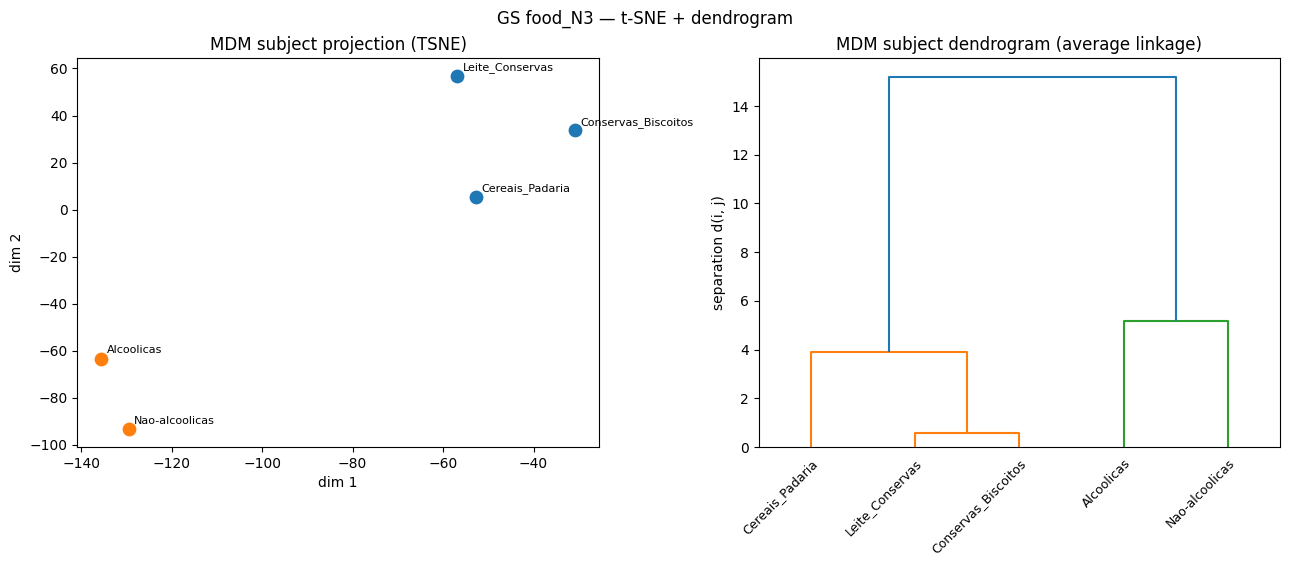

clusters: {'Alcoolicas': 2, 'Nao-alcoolicas': 2, 'Cereais_Padaria': 1, 'Leite_Conservas': 1, 'Conservas_Biscoitos': 1}
nearest neighbours (k=2):
  Alcoolicas: [('Nao-alcoolicas', 5.178510627669311), ('Cereais_Padaria', 10.10677233059323)]
  Nao-alcoolicas: [('Alcoolicas', 5.178510627669311), ('Cereais_Padaria', 16.216312568520152)]
  Cereais_Padaria: [('Conservas_Biscoitos', 2.0126368564133372), ('Leite_Conservas', 5.806856010388856)]
  Leite_Conservas: [('Conservas_Biscoitos', 0.5674067624277086), ('Cereais_Padaria', 5.806856010388856)]
  Conservas_Biscoitos: [('Leite_Conservas', 0.5674067624277086), ('Cereais_Padaria', 2.0126368564133372)]


In [13]:
individuals_f = fit_individual_structures(
    subjects_f,
    method="hc",
    nbf=NBF,
    node_names=node_names_f,
    subject_ids=subject_ids_f,
    n_jobs=-1,
    verbose=True,
)
dist_f = compute_mdm_distance(
    individuals_f,
    metric="lpl_separation",
    nbf=NBF,
    node_names=node_names_f,
    subject_ids=subject_ids_f,
    verbose=True,
)

D = np.asarray(dist_f.matrix, dtype=float)
iu = np.triu_indices_from(D, k=1)
vals = D[iu]
print(
    f"food_N3 distances: min={vals.min():.3f}, max={vals.max():.3f}, "
    f"mean={vals.mean():.3f}, CV={vals.std() / vals.mean():.3f}"
)

fig = plot_group_embedding(dist_f, technique="tsne", n_clusters=2, random_state=0)
plt.suptitle("GS food_N3 — t-SNE + dendrogram", y=1.02)
plt.show()

labels_f = suggest_clusters(dist_f, max_clusters=4)
print("clusters:", dict(zip(subject_ids_f, labels_f.tolist())))
print("nearest neighbours (k=2):")
for sid in subject_ids_f:
    print(f"  {sid}: {nearest_neighbours(dist_f, subject=sid, k=2)}")

## 8. GS — products via lags (`products_N3`)

One subject per SKU. Each series becomes a 3-column lag panel
`[y_t, y_{t-1}, y_{t-2}]` so all products share N=3 for GS (same idea as
`gs_embedding_products_N3_tsne`).

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}


{'n_subjects': 15, 'n_nodes': 3, 'node_names': ['lag0', 'lag1', 'lag2'], 'subject_ids': ['Beer-can', 'Beer-large', 'Beer-ret', 'Rice', 'Beans', 'Bread', 'Soy oil', 'Tomato', 'Milk', 'Yogurt', 'Soda-1.5L', 'Soda-can', 'Juice', 'Cereal bar', 'Chocolate'], 'T_per_subject': [178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178], 'T_min': 178, 'T_max': 178, 'shapes': [(178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3)]}
[distance] fitting individual structure for subject Beer-can


  0%|          | 3/1000000 [00:01<117:40:33,  2.36it/s]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}


[distance] fitting individual structure for subject Beer-large


  0%|          | 2/1000000 [00:01<158:56:31,  1.75it/s]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}


...

[distance] fitting individual structure for subject Chocolate


  0%|          | 0/1000000 [00:00<?, ?it/s]


[distance] computing 105 pairs (n_jobs=None)


Computing pairwise distances: 0it [00:00, ?it/s]INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
  0%|          | 2/1000000 [00:02<286:56:53,  1.03s/it]
Computing pairwise distances: 1it [00:04,  4.10s/it]INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 'lag1': 'N', 'lag2': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'lag0': 'N', 

[distance] d(Beer-can,Beer-large) = 19.827
[distance] d(Beer-can,Beer-ret) = 0.000
[distance] d(Beer-can,Rice) = 3.671
[distance] d(Beer-can,Beans) = 0.146
[distance] d(Beer-can,Bread) = 0.015
[distance] d(Beer-can,Soy oil) = 15.743
[distance] d(Beer-can,Tomato) = 1.028
[distance] d(Beer-can,Milk) = 1.074
[distance] d(Beer-can,Yogurt) = 18.476
[distance] d(Beer-can,Soda-1.5L) = 0.000
[distance] d(Beer-can,Soda-can) = 0.000
[distance] d(Beer-can,Juice) = 16.090
[distance] d(Beer-can,Cereal bar) = 15.723
[distance] d(Beer-can,Chocolate) = 32.068
[distance] d(Beer-large,Beer-ret) = 0.000
[distance] d(Beer-large,Rice) = 3.671
[distance] d(Beer-large,Beans) = 0.146
[distance] d(Beer-large,Bread) = 0.015
[distance] d(Beer-large,Soy oil) = 2.341
[distance] d(Beer-large,Tomato) = 1.028
[distance] d(Beer-large,Milk) = 1.074
[distance] d(Beer-large,Yogurt) = 2.917
[distance] d(Beer-large,Soda-1.5L) = 0.000
[distance] d(Beer-large,Soda-can) = 0.000
[distance] d(Beer-large,Juice) = 1.387
[distance

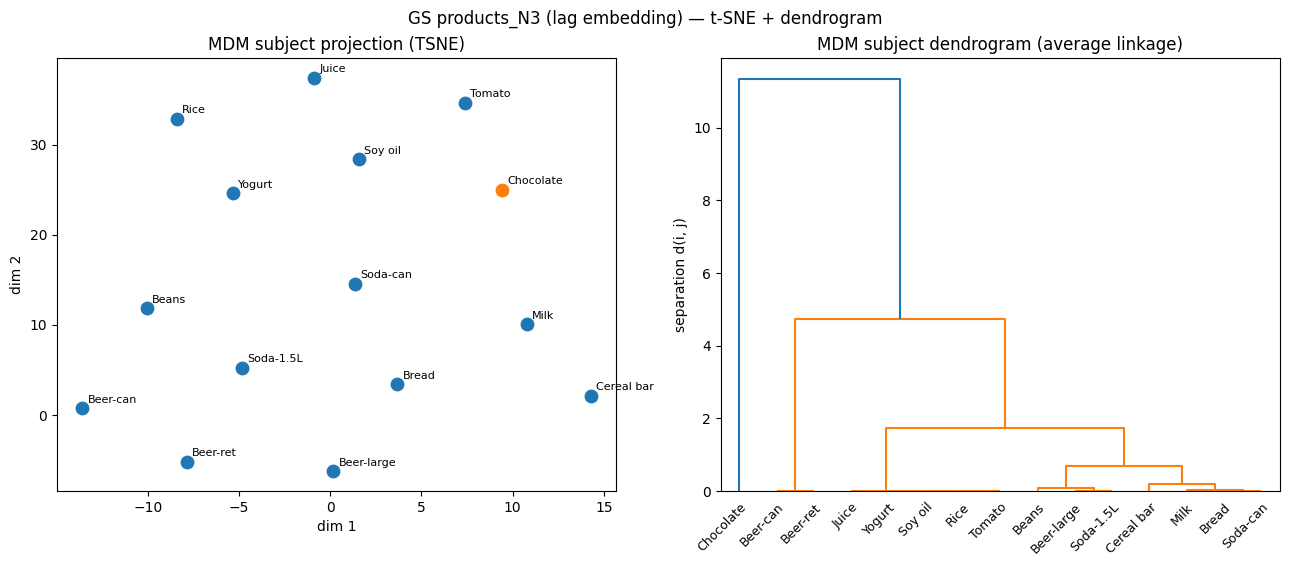

clusters: {'Beer-can': 1, 'Beer-large': 1, 'Beer-ret': 1, 'Rice': 1, 'Beans': 1, 'Bread': 1, 'Soy oil': 1, 'Tomato': 1, 'Milk': 1, 'Yogurt': 1, 'Soda-1.5L': 1, 'Soda-can': 1, 'Juice': 1, 'Cereal bar': 1, 'Chocolate': 2}
nearest neighbours (k=2) — first 5 SKUs:
  Beer-can: [('Beer-ret', 0.0), ('Soda-1.5L', 0.0)]
  Beer-large: [('Beer-ret', 0.0), ('Soda-1.5L', 0.0)]
  Beer-ret: [('Beer-can', 0.0), ('Beer-large', 0.0)]
  Rice: [('Soy oil', 0.0), ('Tomato', 0.0)]
  Beans: [('Soda-1.5L', 0.0), ('Soda-can', 0.0)]


In [14]:
short_ids = [SKU_DAG_LABELS.get(s, s) for s in skus]
subjects_p, subject_ids_p, node_names_p = product_lag_subjects(
    sales, n_lags=3, subject_ids=short_ids
)
print(cohort_summary(subjects_p, subject_ids_p, node_names_p))

individuals_p = fit_individual_structures(
    subjects_p,
    method="hc",
    nbf=NBF,
    node_names=node_names_p,
    subject_ids=subject_ids_p,
    n_jobs=-1,
    verbose=True,
)
dist_p = compute_mdm_distance(
    individuals_p,
    metric="lpl_separation",
    nbf=NBF,
    node_names=node_names_p,
    subject_ids=subject_ids_p,
    verbose=True,
)

D = np.asarray(dist_p.matrix, dtype=float)
iu = np.triu_indices_from(D, k=1)
vals = D[iu]
print(
    f"products_N3 distances: min={vals.min():.3f}, max={vals.max():.3f}, "
    f"mean={vals.mean():.3f}, CV={vals.std() / vals.mean():.3f}"
)

fig = plot_group_embedding(dist_p, technique="tsne", n_clusters=2, random_state=0)
plt.suptitle("GS products_N3 (lag embedding) — t-SNE + dendrogram", y=1.02)
plt.show()

labels_p = suggest_clusters(dist_p, max_clusters=4)
print("clusters:", dict(zip(subject_ids_p, labels_p.tolist())))
print("nearest neighbours (k=2) — first 5 SKUs:")
for sid in subject_ids_p[:5]:
    print(f"  {sid}: {nearest_neighbours(dist_p, subject=sid, k=2)}")

## 9. Takeaways

| Goal | Cohort | Why |
| --- | --- | --- |
| Product structure / anomalies | 15 SKUs | Full multivariate panel |
| Hierarchy DAGs | C3 / C4 sums | Coarser product-line / type graph |
| **IS / VTS** | **Monthly, shared N=7** | Same node semantics across "individuals" |
| **GS food** | Food groups N=3 | Equal N, category-level distance |
| **GS products** | Lag panels N=3 | Equal N per SKU without cross-SKU aggregation |

```python
# APIs exercised: 
- MDM()
- detect_anomalies()
- plot_anomalies()
- plot_dag(style="graphviz")
- fit_individual_structures()
- compute_vts()
- aggregate_individual_structures()
- compute_mdm_distance()
- plot_group_embedding()
- suggest_clusters
- nearest_neighbours()
```